In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
import os
print(os.getcwd())

C:\Users\HARPAL


In [4]:
print(os.listdir())

['.ai-navigator', '.anaconda', '.conda', '.condarc', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.mamba', '.matplotlib', '.spyder-py3', '.vscode', '1757262151.ipynb', 'anaconda3', 'AppData', 'Application Data', 'capstone project.ipynb', 'Contacts', 'Cookies', 'CrossDevice', 'Deep lerning.ipynb', 'Documents', 'Downloads', 'Exploratory Data Analysis (EDA).ipynb', 'Favorites', 'Feature Extraction and Price Prediction for Mobile Phones.ipynb', 'Jedi', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'practice file .txt', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'source', 'Start Menu', 'Templates', 'Untitl

In [5]:
df = pd.read_excel(r"D:\project\pro 4\Processed_Flipdata.xlsx")

In [6]:
print(df.head())

   Unnamed: 0            Model        Colour  Memory  RAM  Battery_  \
0           0  Infinix SMART 7   Night Black      64    4      6000   
1           1  Infinix SMART 7    Azure Blue      64    4      6000   
2           2     MOTOROLA G32  Mineral Gray     128    8      5000   
3           3         POCO C50    Royal Blue      32    2      5000   
4           4  Infinix HOT 30i      Marigold     128    8      5000   

  Rear Camera Front Camera  AI Lens  Mobile Height  \
0        13MP          5MP        1          16.76   
1        13MP          5MP        1          16.76   
2        50MP         16MP        0          16.64   
3         8MP          5MP        0          16.56   
4        50MP          5MP        1          16.76   

                   Processor_  Prize  
0  Unisoc Spreadtrum SC9863A1   7299  
1  Unisoc Spreadtrum SC9863A1   7299  
2     Qualcomm Snapdragon 680  11999  
3          Mediatek Helio A22   5649  
4                         G37   8999  


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 50.8+ KB
None


In [8]:
print(df.describe())

       Unnamed: 0      Memory         RAM     Battery_     AI Lens  \
count  541.000000  541.000000  541.000000   541.000000  541.000000   
mean   289.711645  110.550832    5.397412  4871.587800    0.062847   
std    182.359185   60.600694    1.984923   780.148862    0.242911   
min      0.000000   16.000000    2.000000   800.000000    0.000000   
25%    135.000000   64.000000    4.000000  5000.000000    0.000000   
50%    273.000000  128.000000    6.000000  5000.000000    0.000000   
75%    434.000000  128.000000    8.000000  5000.000000    0.000000   
max    642.000000  256.000000    8.000000  7000.000000    1.000000   

       Mobile Height         Prize  
count     541.000000    541.000000  
mean       16.431201  16228.375231  
std         2.523553  10793.588322  
min         4.500000    920.000000  
25%        16.510000   9290.000000  
50%        16.710000  13499.000000  
75%        16.940000  19280.000000  
max        41.940000  80999.000000  


In [9]:
df = df.dropna()

In [10]:
df = df.drop("Unnamed: 0", axis=1)

In [11]:
X = df.drop("Prize", axis=1)
y = df["Prize"]

In [12]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['Model', 'Colour', 'Rear Camera', 'Front Camera', 'Processor_'], dtype='object')
Numerical Columns: Index(['Memory', 'RAM', 'Battery_', 'AI Lens', 'Mobile Height'], dtype='object')


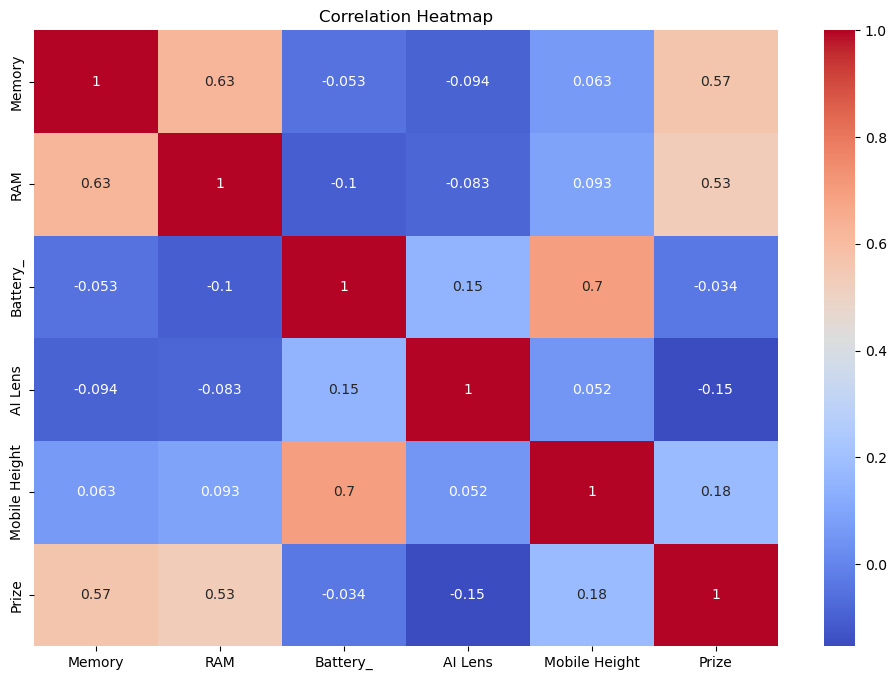

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix["Prize"].sort_values(ascending=False))

Prize            1.000000
Memory           0.566660
RAM              0.532024
Mobile Height    0.176009
Battery_        -0.034297
AI Lens         -0.153691
Name: Prize, dtype: float64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols)
    ],
    remainder="passthrough"
)

In [22]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])

In [23]:
model.fit(X_train, y_train)

C:\Users\HARPAL\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['Model', 'Colour', 'Rear Camera', 'Front Camera', 'Processor_'], dtype='object'))])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importances = model.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

                              Feature  Importance
555                 remainder__Memory    0.277613
557               remainder__Battery_    0.144867
556                    remainder__RAM    0.097603
559          remainder__Mobile Height    0.086408
429            cat__Front Camera_12MP    0.081428
1     cat__Model_APPLE iPhone 14 Plus    0.039634
455  cat__Processor__Google Tensor G2    0.020264
3           cat__Model_Google Pixel 7    0.017857
434            cat__Front Camera_32MP    0.013448
437             cat__Front Camera_5MP    0.013071


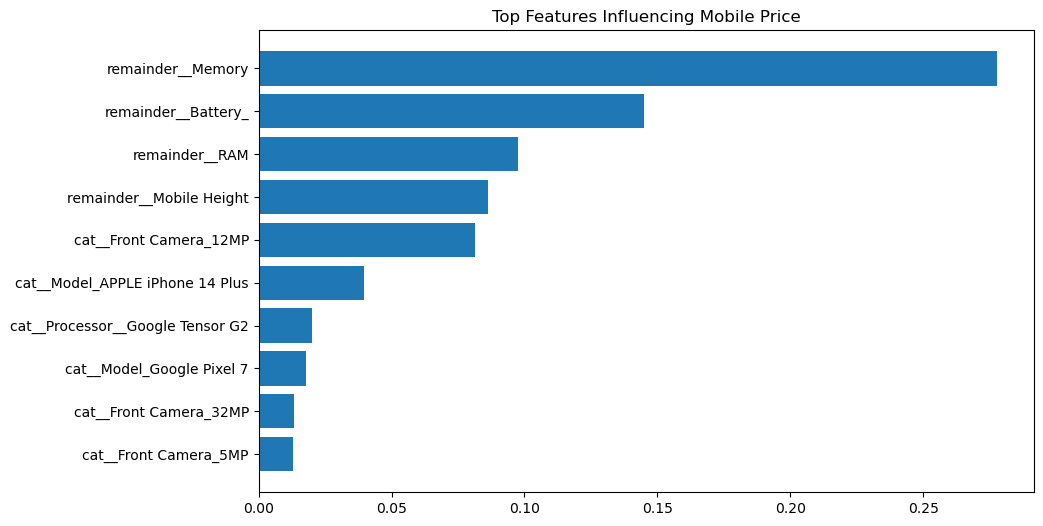

In [27]:
plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top Features Influencing Mobile Price")
plt.show()

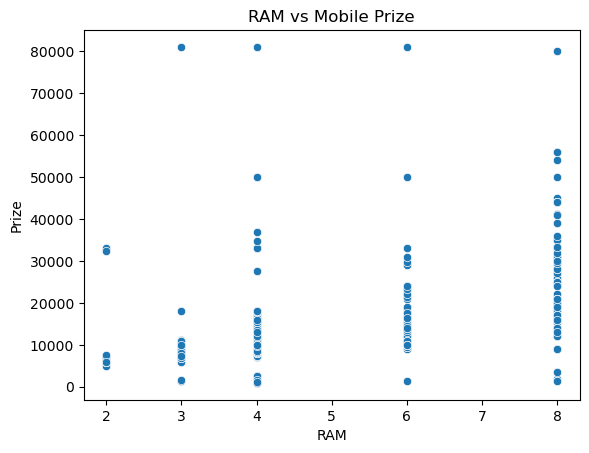

In [33]:
sns.scatterplot(x=df["RAM"], y=df["Prize"])
plt.title("RAM vs Mobile Prize")
plt.show()

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

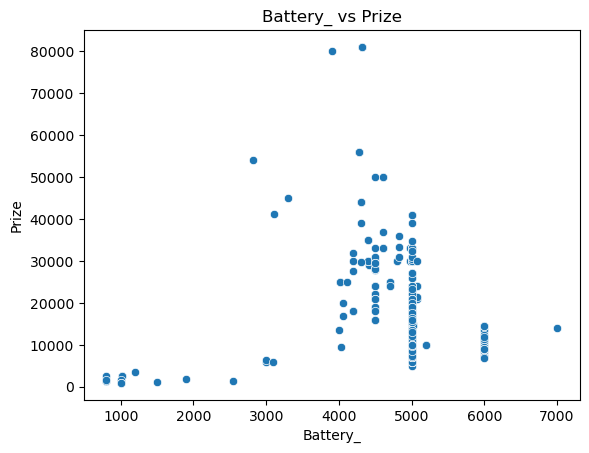

In [39]:
sns.scatterplot(x=df["Battery_"], y=df["Prize"])
plt.title("Battery_ vs Prize")
plt.show()